# Clustering di fasce orarie


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple
from sklearn.cluster import KMeans
import seaborn as sns

## DataFrame Setup


In [2]:
filename = "ASILO_20240208.csv"

# model = "GAVAZZI_WM30"
model = "PM5320"
# building_id = "ED18_CDZ"
building_id = "ASILO.GEN"

df_raw = pd.read_csv(f"./data/{filename}")
df_raw[["datetime", "model", "TotW"]].head(10)


df = df_raw[(df_raw["model"] == model) & (df_raw["id"] == building_id)][
    ["datetime", "TotW"]
]
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime")

df

,TotW
datetime,
2023-07-28 17:13:12.472,8.54
2023-07-28 17:18:12.824,8.49
2023-07-28 17:23:13.169,8.43
2023-07-28 17:28:13.457,8.43
2023-07-28 17:33:13.748,8.64
...,...
2024-02-01 11:25:49.125,6.14
2024-02-01 11:31:19.552,6.28
2024-02-01 11:36:49.985,6.44


In [3]:
def draw_barplot(
    df: pd.DataFrame | pd.Series,
    x: str | pd.Index,
    y: str | pd.Index,
    lw: int = 1,
    figsize: tuple = (20, 5),
    rotation: int = 90,
    visible_labels: bool = True,
    hue: str | None = None,
    title: str | None = None,
) -> Tuple:
    ax, fig = plt.subplots(figsize=figsize)

    ax = sns.barplot(data=df, x=x, y=y, hue=hue, lw=lw)
    ax.set(title=title)
    ax.set_xticklabels(labels=df.index, rotation=rotation)

    ax.grid(axis="y")

    if not visible_labels:
        ax.xaxis.set_ticklabels([])

    return ax, fig

## Approccio #1 - datetime e TotW come features, resample ora per ora


/tmp/ipykernel_80726/2054402446.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=df.index, rotation=rotation)


(<Axes: xlabel='datetime', ylabel='TotW'>,
 <Axes: xlabel='datetime', ylabel='TotW'>)

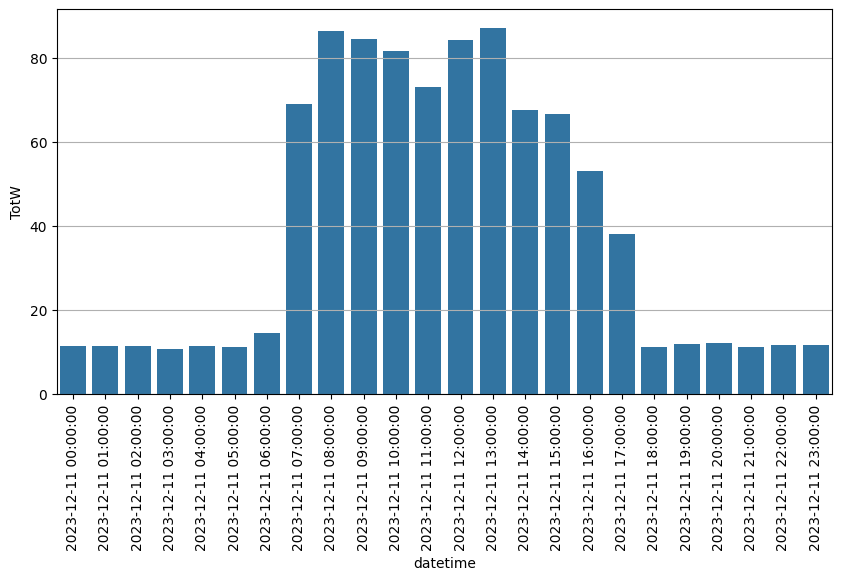

In [4]:
# one day only
from util import plot_dataframe

df_X = df.loc["2023-12-11"]

# * reminder: resampling silently ignores missing indexes - info about missing values might get lost
df_X = df_X.resample("H").sum()

draw_barplot(df_X, x="datetime", y="TotW", figsize=(10, 5))

In [5]:
# prepare training dataset
df_X = pd.DataFrame({"TotW": df_X["TotW"], "datetime": df_X.index})
df_X = df_X.reset_index(drop=True)

# KMeans does not accept datetime features (?), so I'm converting to int
df_X["datetime"] = df_X["datetime"].astype("int")

# apply clustering
df_X["label"] = KMeans(n_init="auto", n_clusters=4).fit_predict(df_X)

df_X.head(5)

,TotW,datetime,label
0,11.37,1702252800000000000,1
1,11.41,1702256400000000000,1
2,11.39,1702260000000000000,1
3,10.85,1702263600000000000,1
4,11.40,1702267200000000000,1


/tmp/ipykernel_80726/2054402446.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=df.index, rotation=rotation)


(<Axes: xlabel='datetime', ylabel='TotW'>,
 <Axes: xlabel='datetime', ylabel='TotW'>)

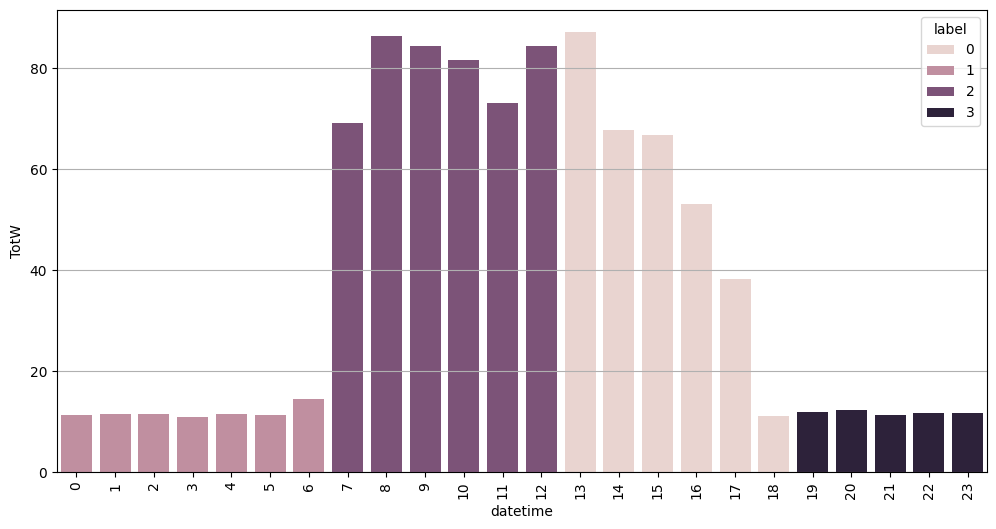

In [6]:
# ensure proper formatting of datetime objects
df_X["datetime"] = pd.to_datetime(df_X["datetime"]).dt.strftime("%H:%M:%S")  # type: ignore

draw_barplot(df_X, y="TotW", x="datetime", hue="label", figsize=(12, 6))

## Approccio #2 - TotW come feature, resample giorno per giorno


In [7]:
df_X = df.resample("D").sum()
df_X["dayofweek"] = df_X.index.dayofweek  # type: ignore

df_X

,TotW,dayofweek
datetime,,
2023-07-28,240.84,4
2023-07-29,584.38,5
2023-07-30,581.90,6
2023-07-31,1747.18,0
2023-08-01,1480.00,1
...,...,...
2024-01-28,334.54,6
2024-01-29,1028.43,0
2024-01-30,958.29,1


/tmp/ipykernel_80726/2054402446.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=df.index, rotation=rotation)


(<Axes: xlabel='datetime', ylabel='TotW'>,
 <Axes: xlabel='datetime', ylabel='TotW'>)

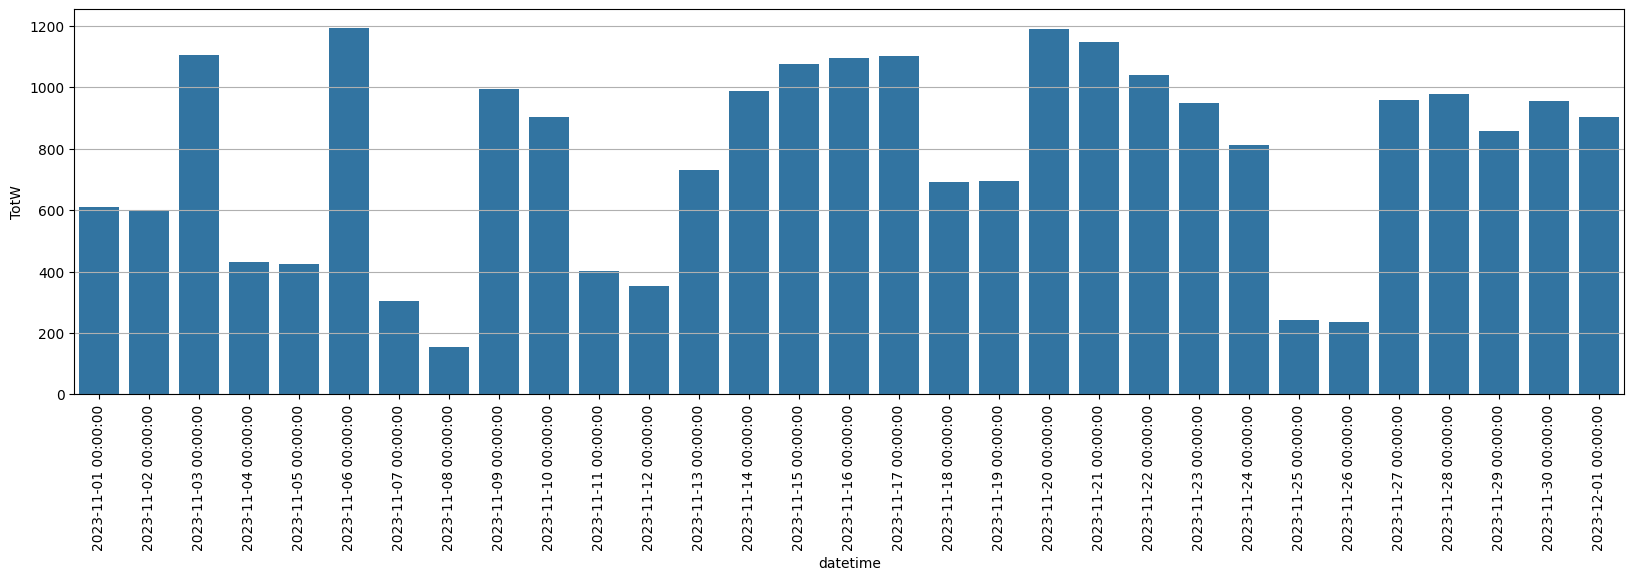

In [8]:
df_X = df_X.loc["2023-11-01":"2023-12-01"]

draw_barplot(df_X, x="datetime", y="TotW")

In [9]:
# apply clustering
df_X["label"] = KMeans(n_init="auto", n_clusters=3, random_state=52).fit_predict(df_X)

df_X.index = df_X.index.strftime("%Y-%m-%d, %a")  # type: ignore

df_X.head(10)

/tmp/ipykernel_80726/1062707285.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X["label"] = KMeans(n_init="auto", n_clusters=3, random_state=52).fit_predict(df_X)


,TotW,dayofweek,label
datetime,,,
"2023-11-01, Wed",609.20,2,2
"2023-11-02, Thu",601.47,3,2
"2023-11-03, Fri",1106.52,4,1
"2023-11-04, Sat",429.66,5,0
"2023-11-05, Sun",424.97,6,0
"2023-11-06, Mon",1193.95,0,1
"2023-11-07, Tue",303.73,1,0
"2023-11-08, Wed",152.99,2,0
"2023-11-09, Thu",993.85,3,1


/tmp/ipykernel_80726/2054402446.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=df.index, rotation=rotation)


(<Axes: title={'center': 'ASILO.GEN, PM5320'}, xlabel='datetime', ylabel='TotW'>,
 <Axes: title={'center': 'ASILO.GEN, PM5320'}, xlabel='datetime', ylabel='TotW'>)

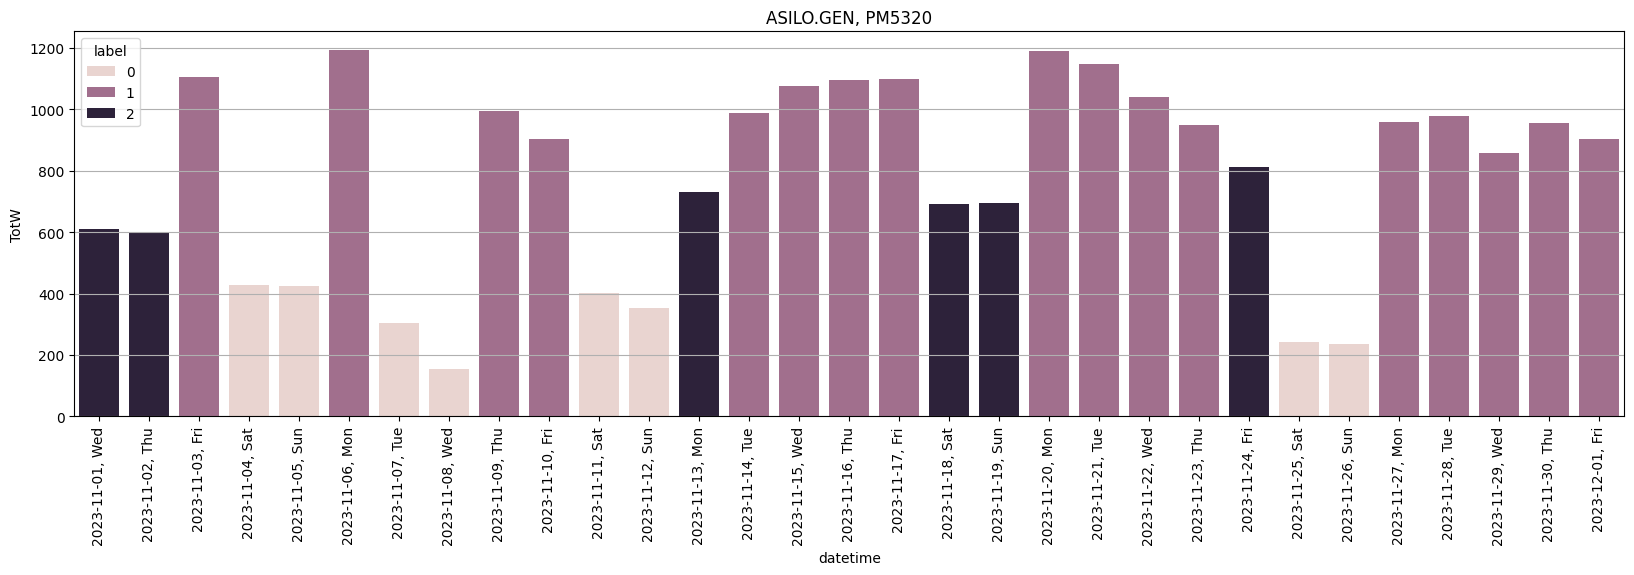

In [10]:
draw_barplot(
    df=df_X,
    x=df_X.index,
    y="TotW",
    hue="label",
    title=f"{building_id}, {model}",
)

/tmp/ipykernel_80726/2054402446.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=df.index, rotation=rotation)


(<Axes: title={'center': 'ASILO.GEN, PM5320 (sorted by dayofweek -> TotW)'}, xlabel='datetime', ylabel='TotW'>,
 <Axes: title={'center': 'ASILO.GEN, PM5320 (sorted by dayofweek -> TotW)'}, xlabel='datetime', ylabel='TotW'>)

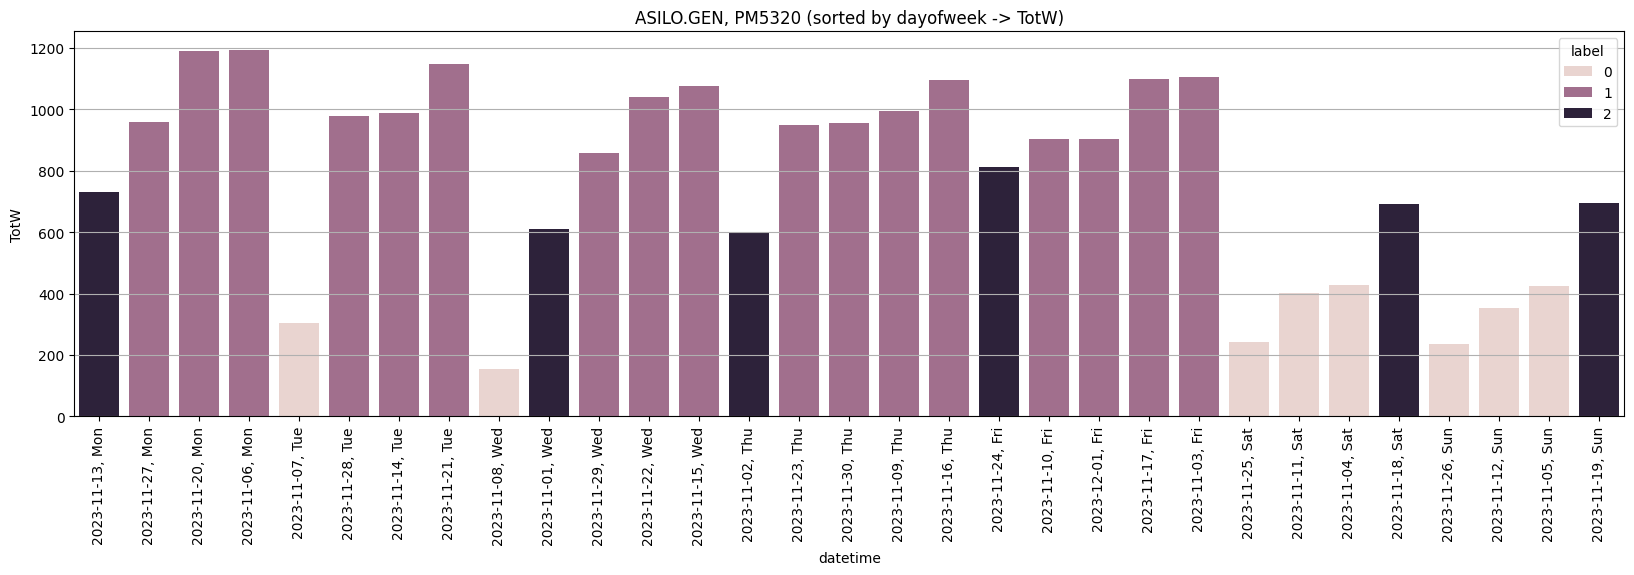

In [11]:
df_X_sorted = df_X.sort_values(["dayofweek", "TotW"])

draw_barplot(
    df=df_X_sorted,
    x=df_X_sorted.index,
    y="TotW",
    hue="label",
    title=f"{building_id}, {model} (sorted by dayofweek -> TotW)",
)

In [12]:
df_X_agg = df_X.groupby("dayofweek").agg({"TotW": ["min", "max", "mean", "std"]})
df_X_agg.style.background_gradient()

In [13]:
df_X_perlabel = df_X.groupby("label").agg({"TotW": ["min", "max", "mean", "std"]})
df_X_perlabel.style.background_gradient()

Risultati:

1. **pattern negli orari**: giorni lun-ven sono molto spesso parte dei cluster dei valori grandi, mentre sab-dom sono molto spesso parte del cluster dei valori piccoli

   - studio ora per ora va effettuato per determinare come variano i consumi "solitamente"

2. **definizione per la baseline**: il cluster dei valori piccoli induce una definizione per la baseline, presentando dei valori di funzionamento minimo
3. **idea per rilevamento anomalie**: il rilevamento delle anomalie potrebbe essere effettuato utilizzando la media come valore base e la deviazione standard come intorno


Problemi:

1. **l'approccio va generalizzato a minuti, secondi, etc.**. Siamo sicuri che funzionerà anche in questo caso?


## Approccio #2.1 - TotW come features, resample min per min


In [14]:
df_X = df.resample("1min").sum()

df_X

,TotW
datetime,
2023-07-28 17:13:00,8.54
2023-07-28 17:14:00,0.00
2023-07-28 17:15:00,0.00
2023-07-28 17:16:00,0.00
2023-07-28 17:17:00,0.00
...,...
2024-02-01 11:43:00,0.00
2024-02-01 11:44:00,0.00
2024-02-01 11:45:00,0.00


In [15]:
df_X = df_X.loc["2023-09-01":"2023-09-02"]

# draw_barplot(df_X, x="datetime", y="TotW", visible_labels=False, lw=0)

In [16]:
# apply clustering
# 2 clusters seem enough to describe the difference between baseline and higher-than-baseline consumptions
df_X["label"] = KMeans(n_init="auto", n_clusters=2, random_state=52).fit_predict(df_X)

df_X.head(10)

/tmp/ipykernel_80726/2470552631.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X["label"] = KMeans(n_init="auto", n_clusters=2, random_state=52).fit_predict(df_X)


,TotW,label
datetime,,
2023-09-01 00:00:00,0.00,0
2023-09-01 00:01:00,1.85,0
2023-09-01 00:02:00,0.00,0
2023-09-01 00:03:00,0.00,0
2023-09-01 00:04:00,0.00,0
2023-09-01 00:05:00,0.00,0
2023-09-01 00:06:00,1.59,0
2023-09-01 00:07:00,0.00,0
2023-09-01 00:08:00,0.00,0


In [17]:
# add time features, useful when/if using this data as a training dataset
# * note: time features are added post-clustering on purpose, as we don't
# * want them as part of the clustering dataset
df_X["hour"] = df_X.index.hour  # type: ignore
df_X["dayofweek"] = df_X.index.dayofweek  # type: ignore
df_X["week"] = df_X.index.day_of_year // 7  # type: ignore

df_X.index = df_X.index.strftime("%Y-%m-%d, %H:%M:%S, %a")  # type: ignore

/tmp/ipykernel_80726/1523992859.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X["hour"] = df_X.index.hour  # type: ignore
/tmp/ipykernel_80726/1523992859.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X["dayofweek"] = df_X.index.dayofweek  # type: ignore
/tmp/ipykernel_80726/1523992859.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

In [18]:
# draw_barplot(df_X, y="TotW", x="datetime", hue="label", lw=0, figsize=(15, 6), visible_labels=False)

In [19]:
# df_X_sorted = df_X.sort_values(["dayofweek", "TotW"])

# draw_barplot(
#     df=df_X_sorted,
#     x=df_X_sorted.index,
#     y="TotW",
#     hue="label",
#     title=f"{building_id}, {model} (sorted by dayofweek -> TotW)",
#     figsize=(300, 8),
#     lw=0,
# )

In [20]:
# df_X_dropzero = df_X[df_X["TotW"] != 0]

# df_X_sorted = df_X_dropzero.sort_values(["dayofweek", "TotW"])

# draw_barplot(
#     df=df_X_sorted,
#     x=df_X_sorted.index,
#     y="TotW",
#     hue="label",
#     title=f"{building_id}, {model} (sorted by dayofweek -> TotW)",
#     figsize=(300, 8),
#     lw=0,
# )

In [21]:
df_X_agg = df_X.groupby("dayofweek").agg({"TotW": ["min", "max", "mean", "std"]})
df_X_agg.style.background_gradient()

In [22]:
df_X_perlabel = df_X.groupby("label").agg({"TotW": ["min", "max", "mean", "std"]})
df_X_perlabel.style.background_gradient()

In [23]:
df_X["zscore_TotW"] = (df_X["TotW"] - df_X["TotW"].mean()) / df_X["TotW"].std(ddof=0)
df_X[df_X["zscore_TotW"] >= 4]

/tmp/ipykernel_80726/3727007646.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X["zscore_TotW"] = (df_X["TotW"] - df_X["TotW"].mean()) / df_X["TotW"].std(ddof=0)


,TotW,label,hour,dayofweek,week,zscore_TotW
datetime,,,,,,
"2023-09-01, 08:02:00, Fri",9.99,1,8,4,34,4.055289
"2023-09-01, 08:07:00, Fri",10.53,1,8,4,34,4.293857
"2023-09-01, 08:12:00, Fri",10.83,1,8,4,34,4.426395
"2023-09-01, 08:17:00, Fri",11.51,1,8,4,34,4.726813
"2023-09-01, 08:22:00, Fri",11.04,1,8,4,34,4.519171
...,...,...,...,...,...,...
"2023-09-01, 14:52:00, Fri",10.35,1,14,4,34,4.214334
"2023-09-01, 14:57:00, Fri",10.66,1,14,4,34,4.351290
"2023-09-01, 15:02:00, Fri",10.55,1,15,4,34,4.302693


In [24]:
df_sunday = df_X[df_X["dayofweek"] == 6]
df_sunday["zscore_TotW"] = (df_sunday["TotW"] - df_sunday["TotW"].mean()) / df_sunday[
    "TotW"
].std(ddof=0)

df_sunday.mean()

TotW          NaN
label         NaN
hour          NaN
dayofweek     NaN
week          NaN
zscore_TotW   NaN
dtype: float64

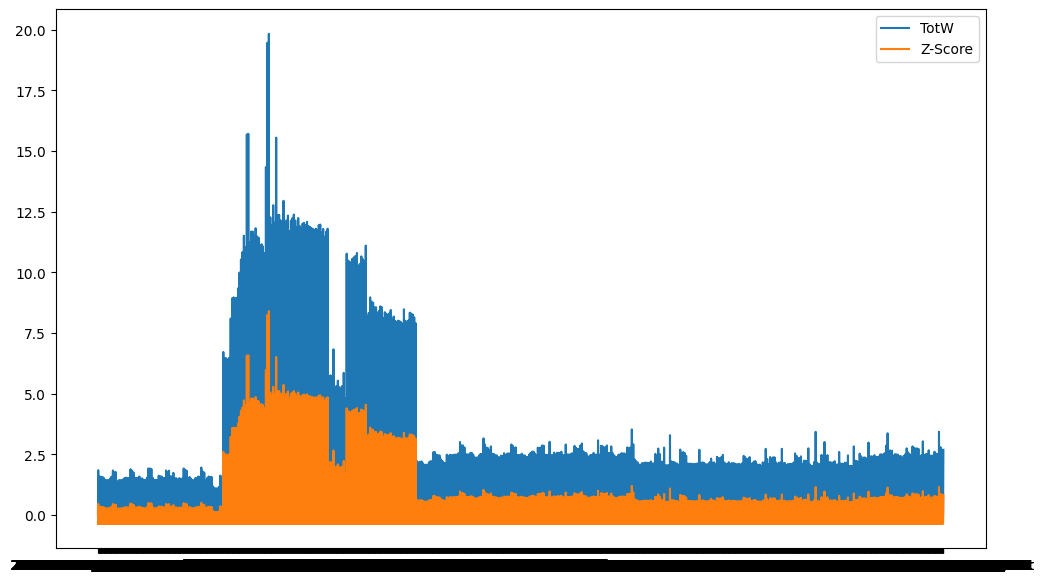

In [25]:
plt.figure(figsize=(12, 7))

plt.plot(df_X["TotW"], label="TotW")
plt.plot(df_X["zscore_TotW"], label="Z-Score")

# plt.grid()
plt.legend()
plt.show()

### Risultati:

- l'approccio si generalizza perfettamente a una versione con resampling minuto per minuto. Per motivi di visualizzazione, ho droppato le righe contenenti TotW == 0, permettendo di visualizzare un grafico molto simile a quello ottenuto per la versione con resampling giorno per giorno.
- usando KMeans con 2 cluster, si forma:
  1. un cluster contenente i valori "bassi", che potrebbero rappresentare una baseline;
  2. un cluster contenente i valori "non-bassi", che potrebbero rappresentare i valori di consumo durante le fasce operative.
